# 😴 Sleep Disorder Predictive Analysis

Predicting **Insomnia**, **Sleep Apnea**, or **No Disorder** using three ML classifiers with cross-validation, feature importance, and a fully-functional prediction function.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


## 1. Load & Explore Data

In [2]:
df = pd.read_csv('sleep_health_lifestyle_dataset.csv')
print(f'Shape: {df.shape}')
print(f'\nSleep Disorder distribution (including NaN):')
print(df['Sleep Disorder'].value_counts(dropna=False))
df.head()

Shape: (400, 13)

Sleep Disorder distribution (including NaN):
Sleep Disorder
NaN            290
Insomnia        79
Sleep Apnea     31
Name: count, dtype: int64


,Person ID,Gender,Age,Occupation,Sleep Duration (hours),Quality of Sleep (scale: 1-10),Physical Activity Level (minutes/day),Stress Level (scale: 1-10),BMI Category,Blood Pressure (systolic/diastolic),Heart Rate (bpm),Daily Steps,Sleep Disorder
0,1,Male,29,Manual Labor,7.4,7.0,41,7,Obese,124/70,91,8539,NaN
1,2,Female,43,Retired,4.2,4.9,41,5,Obese,131/86,81,18754,NaN
2,3,Male,44,Retired,6.1,6.0,107,4,Underweight,122/70,81,2857,NaN
3,4,Male,29,Office Worker,8.3,10.0,20,10,Obese,124/72,55,6886,NaN
4,5,Male,67,Retired,9.1,9.5,19,4,Overweight,133/78,97,14945,Insomnia


## 2. Preprocessing

**Key improvements over v1:**
- `NaN` → `'None'` so we predict all three classes (not just 2)
- Blood pressure split into numeric `Systolic_BP` and `Diastolic_BP`
- Consistent column naming

In [3]:
# Fill NaN disorder as 'None' — keeps the full 3-class problem
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# Parse blood pressure into two numeric features
df[['Systolic_BP', 'Diastolic_BP']] = (
    df['Blood Pressure (systolic/diastolic)']
    .str.split('/', expand=True)
    .astype(int)
)

# Encode target
le = LabelEncoder()
y = le.fit_transform(df['Sleep Disorder'])
print('Classes:', le.classes_)

# Build feature matrix (drop ID, raw BP string, target)
X = df.drop(columns=['Person ID', 'Sleep Disorder', 'Blood Pressure (systolic/diastolic)'])
X = pd.get_dummies(X)  # one-hot encode Gender, Occupation, BMI Category
print(f'Features ({X.shape[1]}):', list(X.columns))

# Train / test split — stratified to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain size: {len(X_train)}  |  Test size: {len(X_test)}')


Classes: ['Insomnia' 'None' 'Sleep Apnea']
Features (19): ['Age', 'Sleep Duration (hours)', 'Quality of Sleep (scale: 1-10)', 'Physical Activity Level (minutes/day)', 'Stress Level (scale: 1-10)', 'Heart Rate (bpm)', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP', 'Gender_Female', 'Gender_Male', 'Occupation_Manual Labor', 'Occupation_Office Worker', 'Occupation_Retired', 'Occupation_Student', 'BMI Category_Normal', 'BMI Category_Obese', 'BMI Category_Overweight', 'BMI Category_Underweight']

Train size: 320  |  Test size: 80


## 3. Model Comparison (5-Fold Cross-Validation)

In [4]:
models = {
    'Logistic Regression':  (LogisticRegression(class_weight='balanced', max_iter=1000), True),
    'Random Forest':        (RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42), False),
    'Gradient Boosting':    (GradientBoostingClassifier(n_estimators=200, random_state=42), False),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, (model, use_scaled) in models.items():
    Xtr = X_train_s if use_scaled else X_train
    Xte = X_test_s  if use_scaled else X_test
    
    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='accuracy')
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    test_acc = accuracy_score(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'use_scaled': use_scaled,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_acc': test_acc,
        'y_pred': y_pred,
    }
    print(f'{name:25s} CV: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}  |  Test Acc: {test_acc:.3f}')

# Pick best model by CV score
best_name = max(results, key=lambda k: results[k]['cv_mean'])
best = results[best_name]
print(f'\n✅ Best model: {best_name}  (CV {best["cv_mean"]:.3f})')


Logistic Regression       CV: 0.378 ± 0.036  |  Test Acc: 0.412
Random Forest             CV: 0.719 ± 0.017  |  Test Acc: 0.725
Gradient Boosting         CV: 0.616 ± 0.032  |  Test Acc: 0.725

✅ Best model: Random Forest  (CV 0.719)


## 4. Accuracy Comparison Chart

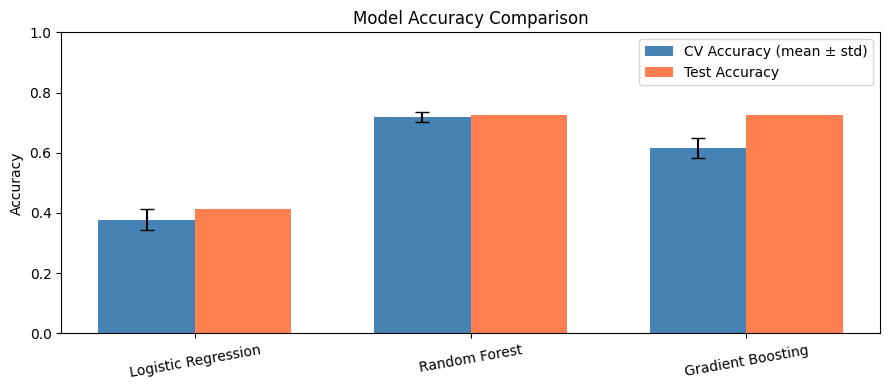

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
names   = list(results.keys())
cv_means = [results[n]['cv_mean'] for n in names]
cv_stds  = [results[n]['cv_std']  for n in names]
test_accs = [results[n]['test_acc'] for n in names]

x = np.arange(len(names))
w = 0.35
ax.bar(x - w/2, cv_means, w, yerr=cv_stds, capsize=5, label='CV Accuracy (mean ± std)', color='steelblue')
ax.bar(x + w/2, test_accs, w, label='Test Accuracy', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=10)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Best Model — Detailed Report

In [6]:
print(f'--- {best_name} ---\n')
print(classification_report(y_test, best['y_pred'], target_names=le.classes_))


--- Random Forest ---

              precision    recall  f1-score   support

    Insomnia       0.00      0.00      0.00        16
        None       0.72      1.00      0.84        58
 Sleep Apnea       0.00      0.00      0.00         6

    accuracy                           0.72        80
   macro avg       0.24      0.33      0.28        80
weighted avg       0.53      0.72      0.61        80



## 6. Confusion Matrix

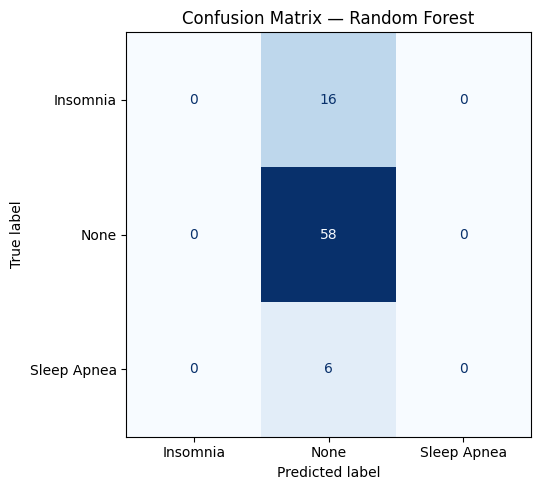

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()


## 7. Feature Importance (Best Tree-Based Model)

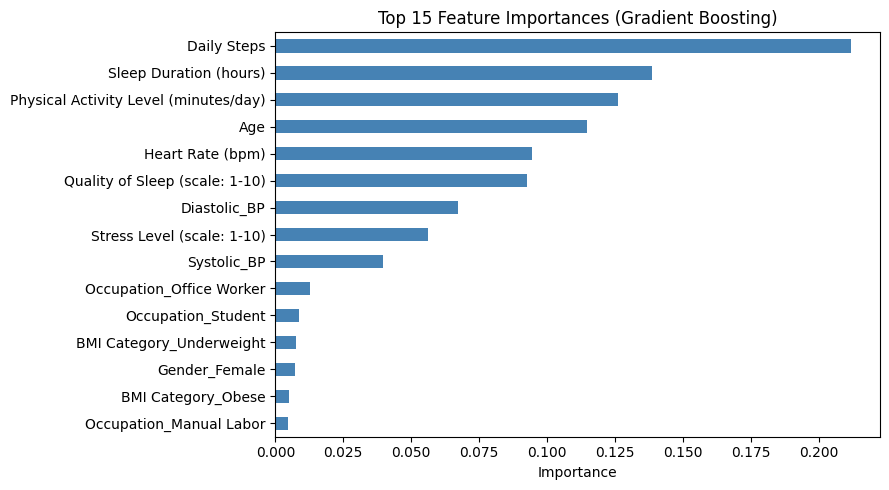

In [8]:
# Use Random Forest or Gradient Boosting for feature importance
tree_model_name = 'Gradient Boosting' if 'Gradient Boosting' in results else 'Random Forest'
tree_model = results[tree_model_name]['model']

importances = pd.Series(tree_model.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
top15.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Importance')
ax.set_title(f'Top 15 Feature Importances ({tree_model_name})')
plt.tight_layout()
plt.show()


## 8. Stress Level vs. Sleep Quality

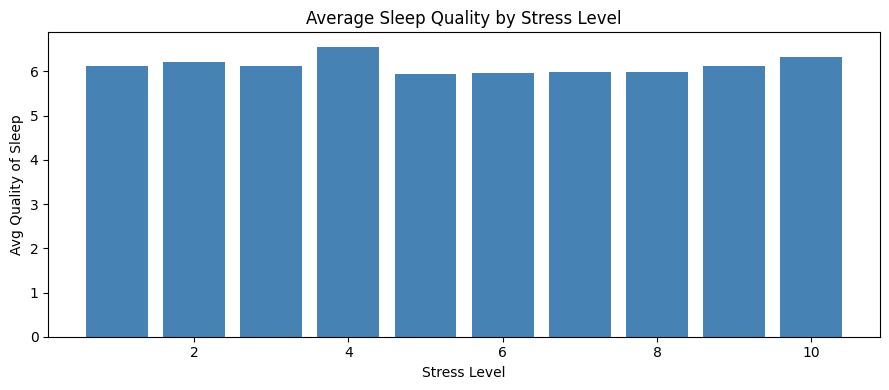

In [9]:
agg = df.groupby('Stress Level (scale: 1-10)')['Quality of Sleep (scale: 1-10)'].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(agg.index, agg.values, color='steelblue')
ax.set_xlabel('Stress Level')
ax.set_ylabel('Avg Quality of Sleep')
ax.set_title('Average Sleep Quality by Stress Level')
plt.tight_layout()
plt.show()


## 9. Prediction Function

Use the **best model** to predict a new person's sleep disorder — with confidence probabilities.

Blood pressure should be passed as a string like `'126/81'`.


In [10]:
def predict_sleep_disorder(
    age, gender, occupation,
    sleep_duration, quality, activity,
    stress, bmi, blood_pressure,
    heart_rate, daily_steps,
    model=None, use_scaled=None
):
    """Predict sleep disorder for a new person and show confidence scores."""
    if model is None:
        model = best['model']
        use_scaled = best['use_scaled']

    # Parse blood pressure
    sys_bp, dia_bp = map(int, blood_pressure.split('/'))

    new_person = pd.DataFrame([{
        'Age':                                    age,
        'Gender':                                 gender,
        'Occupation':                             occupation,
        'Sleep Duration (hours)':                 sleep_duration,
        'Quality of Sleep (scale: 1-10)':         quality,
        'Physical Activity Level (minutes/day)':  activity,
        'Stress Level (scale: 1-10)':             stress,
        'BMI Category':                           bmi,
        'Heart Rate (bpm)':                       heart_rate,
        'Daily Steps':                            daily_steps,
        'Systolic_BP':                            sys_bp,
        'Diastolic_BP':                           dia_bp,
    }])

    new_person = pd.get_dummies(new_person)
    new_person = new_person.reindex(columns=X.columns, fill_value=0)

    if use_scaled:
        new_person = scaler.transform(new_person)

    pred_class  = le.inverse_transform(model.predict(new_person))[0]
    probs       = model.predict_proba(new_person)[0]
    prob_dict   = dict(zip(le.classes_, probs))

    print(f'Prediction : {pred_class}')
    print('Confidence :')
    for cls, p in sorted(prob_dict.items(), key=lambda x: -x[1]):
        bar = '█' * int(p * 30)
        print(f'  {cls:12s} {p:.1%}  {bar}')
    return pred_class, prob_dict

# --- Example ---
predict_sleep_disorder(
    age=52, gender='Female', occupation='Office Worker',
    sleep_duration=4.9, quality=5, activity=87,
    stress=10, bmi='Underweight', blood_pressure='126/81',
    heart_rate=77, daily_steps=6251
)


Prediction : None
Confidence :
  None         90.5%  ███████████████████████████
  Insomnia     6.5%  █
  Sleep Apnea  3.0%  


('None',
 {'Insomnia': np.float64(0.065),
  'None': np.float64(0.905),
  'Sleep Apnea': np.float64(0.03)})